# Kaggle: Regression with an Abalone Dataset — Regularization-Informed Subset Selection and PCR

This notebook builds two required regression models for the Abalone Kaggle late submission:

1. **Regularization-informed best subset model**: Elastic Net/Lasso is used to identify the strongest predictors, then a final subset regression model is fitted using only the selected predictors.
2. **Principal Components Regression (PCR)**: PCA is applied to the processed feature matrix, and a regression model is fitted on the principal components.

The notebook also evaluates model performance, creates Kaggle `submission.csv`, investigates regression assumptions, and provides interpretation guidance.

## 1. Setup and data loading

Place `train.csv` and `test.csv` in the same folder as this notebook, or run the notebook on Kaggle where the files are under `/kaggle/input/playground-series-s4e4/`.

### Compatibility note

This corrected version avoids `mean_squared_error(..., squared=False)` and computes RMSE with `np.sqrt(mean_squared_error(...))`, which works across older and newer scikit-learn versions.


In [11]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.linear_model import ElasticNetCV, RidgeCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.base import BaseEstimator, TransformerMixin

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson


In [12]:

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

def find_file(filename):
    candidates = [
        Path(filename),
        Path("/kaggle/input") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
    if matches:
        return Path(matches[0])
    raise FileNotFoundError(f"Could not find {filename}. Put it beside this notebook or run it on Kaggle.")

train_path = find_file("train.csv")
test_path = find_file("test.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(train.shape, test.shape)
display(train.head())
display(test.head())

(90615, 10) (60411, 9)


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [13]:
# Basic target and ID setup
TARGET = "Rings"
ID_COL = "id" if "id" in train.columns else None

assert TARGET in train.columns, f"Expected target column '{TARGET}' in train.csv"

X = train.drop(columns=[TARGET] + ([ID_COL] if ID_COL else []))
y = train[TARGET].astype(float)

X_test = test.drop(columns=([ID_COL] if ID_COL and ID_COL in test.columns else []))
test_ids = test[ID_COL] if ID_COL and ID_COL in test.columns else pd.Series(np.arange(len(test)), name="id")

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Target summary:")
display(y.describe())

Numeric columns: ['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight']
Categorical columns: ['Sex']
Target summary:


count    90615.000000
mean         9.696794
std          3.176221
min          1.000000
25%          8.000000
50%          9.000000
75%         11.000000
max         29.000000
Name: Rings, dtype: float64

## 2. Metric functions

Kaggle used root mean squared logarithmic error (RMSLE) for this competition. Predictions are clipped at zero because RMSLE requires non-negative values.

In [14]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    pred_train = np.maximum(model.predict(X_train), 0)
    pred_valid = np.maximum(model.predict(X_valid), 0)

    results = {
        "model": name,
        "train_RMSLE": rmsle(y_train, pred_train),
        "valid_RMSLE": rmsle(y_valid, pred_valid),
        "valid_RMSE": np.sqrt(mean_squared_error(y_valid, pred_valid)),
        "valid_MAE": mean_absolute_error(y_valid, pred_valid),
        "valid_R2": r2_score(y_valid, pred_valid),
    }
    return results

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(X_train.shape, X_valid.shape)

(72492, 8) (18123, 8)


## 3. Feature preprocessing

The regularized model uses standardized numeric features, one-hot encoded `Sex`, and optional degree-2 numeric polynomial features. Polynomial terms help capture curvature and interactions while Elastic Net controls overfitting by shrinking weak terms.

In [15]:
# Numeric polynomial pipeline
numeric_poly = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

# Robust handling of scikit-learn versions for OneHotEncoder argument name
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess_poly = ColumnTransformer(
    transformers=[
        ("num", numeric_poly, numeric_cols),
        ("cat", onehot, categorical_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", onehot, categorical_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

## 4. Model 1: Regularization-informed subset selection

Elastic Net is used first to identify a smaller set of useful predictors. Then a final Ridge regression model is trained on only those selected predictors. This satisfies the requirement to use regularization techniques to inform subset selection.

In [16]:
# Fit Elastic Net with cross-validation
elastic_pipe = Pipeline(steps=[
    ("prep", preprocess_poly),
    ("model", ElasticNetCV(
        l1_ratio=[0.10, 0.30, 0.50, 0.70, 0.90, 0.95, 1.00],
        alphas=np.logspace(-4, 1, 80),
        cv=5,
        max_iter=20000,
        random_state=RANDOM_STATE
    ))
])

elastic_pipe.fit(X_train, y_train)

elastic_model = elastic_pipe.named_steps["model"]
feature_names = elastic_pipe.named_steps["prep"].get_feature_names_out()
coef = elastic_model.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "elastic_net_coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

selected_features = coef_df.loc[coef_df["abs_coef"] > 1e-6, "feature"].tolist()

print("Best alpha:", elastic_model.alpha_)
print("Best l1_ratio:", elastic_model.l1_ratio_)
print("Selected feature count:", len(selected_features))
display(coef_df.head(30))
display(coef_df[coef_df["abs_coef"] > 1e-6])

Best alpha: 0.0001
Best l1_ratio: 0.9
Selected feature count: 33


,feature,elastic_net_coef,abs_coef
29,num__Whole weight.1^2,5.509213,5.509213
26,num__Whole weight Whole weight.1,-4.208266,4.208266
8,num__Length Diameter,-3.690869,3.690869
16,num__Diameter Whole weight,3.258340,3.258340
19,num__Diameter Shell weight,3.236651,3.236651
3,num__Whole weight,3.180277,3.180277
33,num__Whole weight.2 Shell weight,-2.943046,2.943046
4,num__Whole weight.1,-2.823875,2.823875
22,num__Height Whole weight.1,-2.740192,2.740192
24,num__Height Shell weight,2.691312,2.691312


,feature,elastic_net_coef,abs_coef
29,num__Whole weight.1^2,5.509213,5.509213
26,num__Whole weight Whole weight.1,-4.208266,4.208266
8,num__Length Diameter,-3.690869,3.690869
16,num__Diameter Whole weight,3.258340,3.258340
19,num__Diameter Shell weight,3.236651,3.236651
3,num__Whole weight,3.180277,3.180277
33,num__Whole weight.2 Shell weight,-2.943046,2.943046
4,num__Whole weight.1,-2.823875,2.823875
22,num__Height Whole weight.1,-2.740192,2.740192
24,num__Height Shell weight,2.691312,2.691312


In [19]:
class FeatureSelectorByName(BaseEstimator, TransformerMixin):
    def __init__(self, selected_feature_names=None, all_feature_names=None):
        self.selected_feature_names = selected_feature_names
        self.all_feature_names = all_feature_names

    def fit(self, X, y=None):
        if self.selected_feature_names is None:
            self.selected_feature_names_ = list(self.all_feature_names)
        else:
            self.selected_feature_names_ = list(self.selected_feature_names)
        self.indices_ = [list(self.all_feature_names).index(f) for f in self.selected_feature_names_]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def get_feature_names_out(self):
        return np.array(self.selected_feature_names_)

# Final subset model: preprocess -> keep ElasticNet-selected predictors -> Ridge
ridge_alphas = np.logspace(-4, 4, 80)

subset_model = Pipeline(steps=[
    ("prep", preprocess_poly),
    ("select", FeatureSelectorByName(selected_features, feature_names)),
    ("model", RidgeCV(alphas=ridge_alphas))
])

subset_model.fit(X_train, y_train)

subset_results = evaluate_model(
    "Regularization-informed subset Ridge",
    subset_model, X_train, y_train, X_valid, y_valid
)

subset_results

{'model': 'Regularization-informed subset Ridge',
 'train_RMSLE': np.float64(0.15613699676788514),
 'valid_RMSLE': np.float64(0.15888580564508747),
 'valid_RMSE': np.float64(1.9480430627997918),
 'valid_MAE': 1.3420699612565656,
 'valid_R2': 0.630574350327548}

In [20]:
# Coefficients for final subset model
subset_coefs = pd.DataFrame({
    "feature": subset_model.named_steps["select"].get_feature_names_out(),
    "ridge_coef": subset_model.named_steps["model"].coef_,
    "abs_coef": np.abs(subset_model.named_steps["model"].coef_)
}).sort_values("abs_coef", ascending=False)

print("Chosen Ridge alpha:", subset_model.named_steps["model"].alpha_)
display(subset_coefs)

Chosen Ridge alpha: 1.1236548001387516


,feature,ridge_coef,abs_coef
0,num__Whole weight.1^2,5.454140,5.454140
4,num__Diameter Shell weight,5.028444,5.028444
1,num__Whole weight Whole weight.1,-4.100797,4.100797
16,num__Length Shell weight,-3.272982,3.272982
3,num__Diameter Whole weight,3.235988,3.235988
2,num__Length Diameter,-3.208083,3.208083
10,num__Diameter Whole weight.1,-2.923923,2.923923
8,num__Height Whole weight.1,-2.839952,2.839952
6,num__Whole weight.2 Shell weight,-2.780339,2.780339
9,num__Height Shell weight,2.755948,2.755948


### Interpretation of Model 1

Interpret the coefficient table using standardized predictors. Larger absolute coefficients indicate stronger association with predicted Rings after accounting for the other selected variables. Positive coefficients increase the predicted number of rings; negative coefficients decrease it. Because Elastic Net selected the predictors before the final model, weak or redundant polynomial terms were removed or shrunk, reducing overfitting compared with an unrestricted polynomial regression.

## 5. Model 2: Principal Components Regression (PCR)

PCR transforms the correlated predictors into orthogonal principal components and then fits a regression model using the selected number of components. The number of components is selected using cross-validation.

In [21]:
# Determine maximum transformed feature count
X_train_prepared = preprocess_poly.fit_transform(X_train)
max_components = min(X_train_prepared.shape[1], X_train_prepared.shape[0] - 1)

pcr_pipe = Pipeline(steps=[
    ("prep", preprocess_poly),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("model", LinearRegression())
])

component_grid = list(range(1, max_components + 1))

pcr_grid = GridSearchCV(
    estimator=pcr_pipe,
    param_grid={"pca__n_components": component_grid},
    scoring=rmsle_scorer,
    cv=5,
    n_jobs=-1
)

pcr_grid.fit(X_train, y_train)
pcr_model = pcr_grid.best_estimator_

print("Best PCR components:", pcr_grid.best_params_["pca__n_components"])
print("Best CV RMSLE:", -pcr_grid.best_score_)

pcr_results = evaluate_model("Principal Components Regression", pcr_model, X_train, y_train, X_valid, y_valid)
pcr_results

Best PCR components: 34
Best CV RMSLE: 0.15633969506291065


{'model': 'Principal Components Regression',
 'train_RMSLE': np.float64(0.15609937574272628),
 'valid_RMSLE': np.float64(0.15884305478958322),
 'valid_RMSE': np.float64(1.948013427907101),
 'valid_MAE': 1.3417088365614196,
 'valid_R2': 0.6305855901265249}

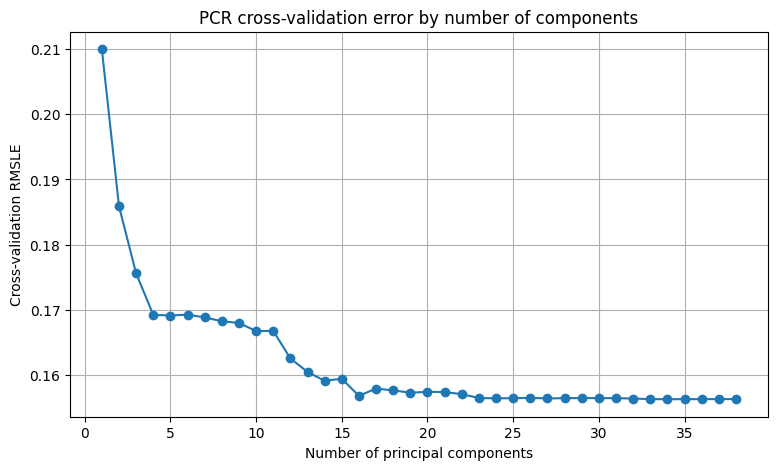

,n_components,mean_RMSLE,std_test_score
0,1,0.209953,0.001651
1,2,0.185899,0.001586
2,3,0.175608,0.003061
3,4,0.169270,0.002105
4,5,0.169162,0.002091
5,6,0.169302,0.002212
6,7,0.168869,0.002108
7,8,0.168286,0.002116
8,9,0.168022,0.001987
9,10,0.166777,0.001905


In [22]:
# Plot PCR cross-validation error by number of components
cv_results = pd.DataFrame(pcr_grid.cv_results_)
cv_results["mean_RMSLE"] = -cv_results["mean_test_score"]
cv_results["n_components"] = cv_results["param_pca__n_components"].astype(int)

plt.figure(figsize=(9, 5))
plt.plot(cv_results["n_components"], cv_results["mean_RMSLE"], marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cross-validation RMSLE")
plt.title("PCR cross-validation error by number of components")
plt.grid(True)
plt.show()

display(cv_results[["n_components", "mean_RMSLE", "std_test_score"]].head(20))

,component,explained_variance_ratio,cumulative_explained_variance
0,1,9.019376e-01,0.901938
1,2,3.787861e-02,0.939816
2,3,1.760446e-02,0.957421
3,4,1.343423e-02,0.970855
4,5,8.975636e-03,0.979831
5,6,7.649477e-03,0.987480
6,7,5.086316e-03,0.992566
7,8,2.047750e-03,0.994614
8,9,1.960343e-03,0.996574
9,10,9.966130e-04,0.997571


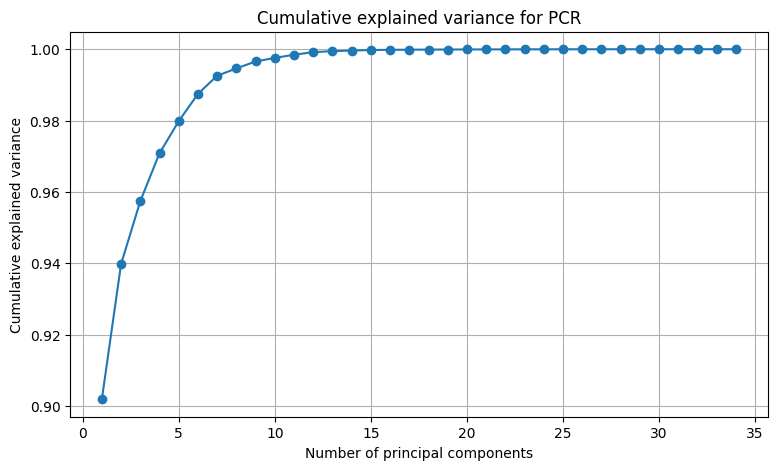

In [23]:
# Explained variance
pca = pcr_model.named_steps["pca"]
explained = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained)

plt.figure(figsize=(9, 5))
plt.plot(explained["component"], explained["cumulative_explained_variance"], marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance for PCR")
plt.grid(True)
plt.show()

In [24]:
# PCR loadings for first few components
pcr_feature_names = pcr_model.named_steps["prep"].get_feature_names_out()
loadings = pd.DataFrame(
    pca.components_.T,
    index=pcr_feature_names,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)]
)

display(loadings.iloc[:, :min(5, pca.n_components_)].sort_values("PC1", key=np.abs, ascending=False).head(20))

,PC1,PC2,PC3,PC4,PC5
num__Length Whole weight,0.175264,-0.030852,-0.054769,-0.029508,0.001008
num__Diameter Whole weight,0.175248,-0.031726,-0.046328,-0.037920,0.001730
num__Whole weight,0.174713,0.042766,-0.075356,-0.036641,0.002137
num__Height Whole weight,0.174429,-0.020381,0.112318,0.062738,0.008402
num__Diameter Whole weight.2,0.173599,-0.039134,-0.062492,0.003445,-0.060677
num__Length Whole weight.2,0.173504,-0.038407,-0.070559,0.011852,-0.061779
num__Height Whole weight.2,0.172857,-0.026781,0.095923,0.105986,-0.052035
num__Height Whole weight.1,0.172667,-0.058844,-0.018505,0.214544,0.027967
num__Length Shell weight,0.172653,0.011540,0.113756,-0.241831,0.027174
num__Diameter Whole weight.1,0.172407,-0.069703,-0.176253,0.115503,0.022125


### Interpretation of Model 2

PCR is most useful when predictors are correlated because PCA converts them into uncorrelated components. The cross-validation plot identifies the number of components that best balances bias and variance. The cumulative explained variance table shows how much feature variation is retained, while the loading table explains which original features contribute most to each component. Unlike the subset model, PCR coefficients are less directly interpretable because the regression is performed on components rather than original variables.

## 6. Compare model performance

In [37]:
results = pd.DataFrame([subset_results, pcr_results]).sort_values("valid_RMSLE")
display(results)

best_model_name = results.iloc[0]["model"]
best_model = subset_model if best_model_name == "Regularization-informed subset Ridge" else pcr_model

print("Best validation model:", best_model_name)

,model,train_RMSLE,valid_RMSLE,valid_RMSE,valid_MAE,valid_R2
1,Principal Components Regression,0.156099,0.158843,1.948013,1.341709,0.630586
0,Regularization-informed subset Ridge,0.156137,0.158886,1.948043,1.342070,0.630574


Best validation model: Principal Components Regression


## 7. Assumption diagnostics

The diagnostics below focus on the final selected subset regression model because it is more directly interpretable than PCR. For regularized models, classical OLS assumptions and p-values are not interpreted in exactly the same way, but residual behavior is still useful for identifying model weaknesses such as nonlinearity, heteroscedasticity, influential observations, and non-normal residuals.

In [38]:
# Build a statsmodels OLS diagnostic model using the selected transformed predictors
prep_fitted = subset_model.named_steps["prep"]
selector_fitted = subset_model.named_steps["select"]

X_train_trans = prep_fitted.transform(X_train)
X_valid_trans = prep_fitted.transform(X_valid)

X_train_sel = selector_fitted.transform(X_train_trans)
X_valid_sel = selector_fitted.transform(X_valid_trans)

selected_names = selector_fitted.get_feature_names_out()

X_train_sm = sm.add_constant(pd.DataFrame(X_train_sel, columns=selected_names, index=X_train.index))
ols_diag = sm.OLS(y_train, X_train_sm).fit()

print(ols_diag.summary())

                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     3862.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:00:24   Log-Likelihood:            -1.4969e+05
No. Observations:               72492   AIC:                         2.994e+05
Df Residuals:                   72458   BIC:                         2.998e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

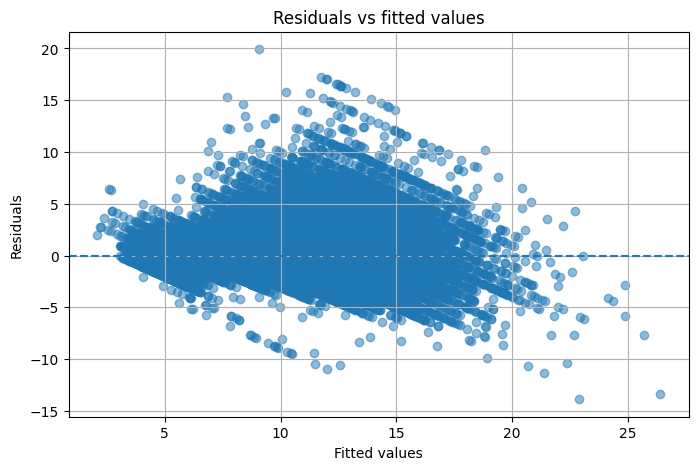

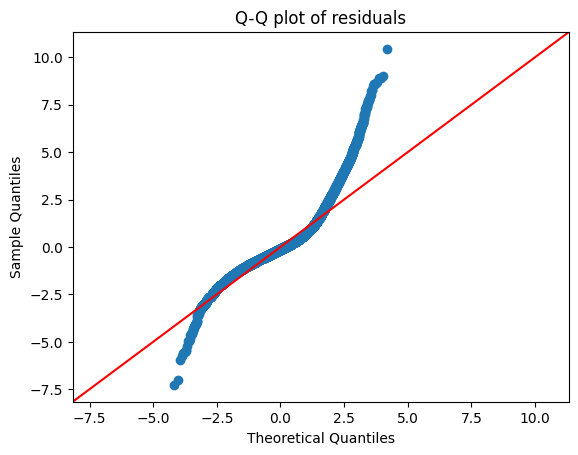

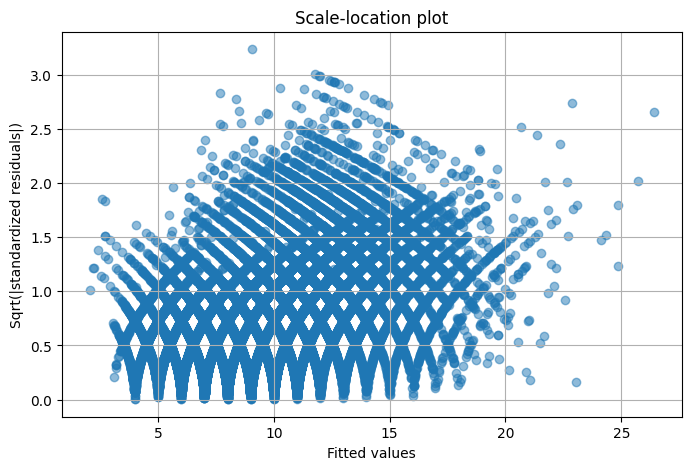

Breusch-Pagan test: {'LM statistic': np.float64(6133.146930262192), 'LM p-value': np.float64(0.0), 'F statistic': np.float64(202.9349741070831), 'F p-value': np.float64(0.0)}
Durbin-Watson statistic: 1.9965730135934565


In [39]:
# Residual diagnostics
fitted = ols_diag.fittedvalues
resid = ols_diag.resid
std_resid = ols_diag.get_influence().resid_studentized_internal

plt.figure(figsize=(8, 5))
plt.scatter(fitted, resid, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted values")
plt.grid(True)
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q plot of residuals")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.5)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|standardized residuals|)")
plt.title("Scale-location plot")
plt.grid(True)
plt.show()

# Tests
bp_test = het_breuschpagan(resid, X_train_sm)
bp_labels = ["LM statistic", "LM p-value", "F statistic", "F p-value"]
bp_results = dict(zip(bp_labels, bp_test))

dw_value = durbin_watson(resid)

print("Breusch-Pagan test:", bp_results)
print("Durbin-Watson statistic:", dw_value)

In [40]:
# VIF for selected predictors
vif_df = pd.DataFrame({
    "feature": X_train_sm.columns,
    "VIF": [variance_inflation_factor(X_train_sm.values, i) for i in range(X_train_sm.shape[1])]
})

display(vif_df.sort_values("VIF", ascending=False))

,feature,VIF
3,num__Length Diameter,112065.960269
28,num__Length^2,35561.567893
4,num__Diameter Whole weight,33831.072682
21,num__Diameter^2,31963.910155
29,num__Length Whole weight,25089.299507
17,num__Length Shell weight,21785.734896
5,num__Diameter Shell weight,18148.173033
31,num__Length Height,16742.157931
26,num__Diameter Height,16228.621589
11,num__Diameter Whole weight.1,8468.068852


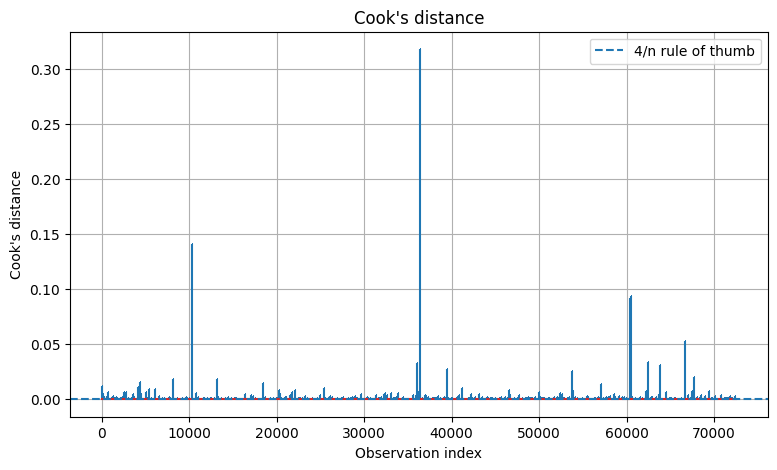

,row_index,cooks_d,fitted,residual
28651,28651,0.318213,20.690158,-10.690158
16384,16384,0.140971,10.536672,-2.536672
30314,30314,0.094037,22.877056,-13.877056
65464,65464,0.092162,6.766864,3.233136
63851,63851,0.053111,22.363178,-10.363178
70819,70819,0.033414,15.206737,-8.206737
18326,18326,0.032629,13.368197,-8.368197
1353,1353,0.031068,24.858617,-5.858617
7154,7154,0.027626,12.342938,6.657062
55852,55852,0.025416,14.412951,-4.412951


In [41]:
# Influence diagnostics: Cook's distance
influence = ols_diag.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(9, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(4 / len(cooks_d), linestyle="--", label="4/n rule of thumb")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's distance")
plt.legend()
plt.grid(True)
plt.show()

influential = pd.DataFrame({
    "row_index": X_train.index,
    "cooks_d": cooks_d,
    "fitted": fitted,
    "residual": resid
}).sort_values("cooks_d", ascending=False)

display(influential.head(10))

## 8. Create Kaggle submission

This creates `submission.csv` using the model with the lower validation RMSLE.

In [42]:
test_predictions = np.maximum(best_model.predict(X_test), 0)

submission = pd.DataFrame({
    "id": test_ids,
    TARGET: test_predictions
})

submission.to_csv("submission.csv", index=False)

display(submission.head())
print("Saved submission.csv")

,id,Rings
0,90615,9.369258
1,90616,9.845272
2,90617,10.466106
3,90618,10.086692
4,90619,7.772542


Saved submission.csv
